In [103]:
import os
import pandas as pd
import numpy as np
import ast
import wfdb
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from scipy import signal as scipy_signal
import pywt  
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import gc

In [104]:
BASE_PATH = r'D:\AOU-Graduation-Project\BioIntellect\AI\ECG\Data\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3'
CSV_PATH  = r'D:\AOU-Graduation-Project\BioIntellect\AI\ECG\App\classification'

train = pd.read_csv(f'{CSV_PATH}\\ptbxl_train.csv')
val   = pd.read_csv(f'{CSV_PATH}\\ptbxl_val.csv')
test  = pd.read_csv(f'{CSV_PATH}\\ptbxl_test.csv')

for df in [train, val, test]:
    df['scp_codes'] = df['scp_codes'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

Train: 17418 | Val: 2183 | Test: 2198


In [105]:
def extract_codes_list(df):
    return df['scp_codes'].apply(lambda x: list(x.keys()))

mlb = MultiLabelBinarizer()
mlb.fit(extract_codes_list(train))

ALL_LABELS  = list(mlb.classes_)   
NUM_CLASSES = len(ALL_LABELS)
print(f"Total unique labels: {NUM_CLASSES}")
print(f"Labels: {ALL_LABELS}")

y_train = mlb.transform(extract_codes_list(train)).astype(np.float32) 
y_val   = mlb.transform(extract_codes_list(val)).astype(np.float32)   
y_test  = mlb.transform(extract_codes_list(test)).astype(np.float32)   

Total unique labels: 71
Labels: ['1AVB', '2AVB', '3AVB', 'ABQRS', 'AFIB', 'AFLT', 'ALMI', 'AMI', 'ANEUR', 'ASMI', 'BIGU', 'CLBBB', 'CRBBB', 'DIG', 'EL', 'HVOLT', 'ILBBB', 'ILMI', 'IMI', 'INJAL', 'INJAS', 'INJIL', 'INJIN', 'INJLA', 'INVT', 'IPLMI', 'IPMI', 'IRBBB', 'ISCAL', 'ISCAN', 'ISCAS', 'ISCIL', 'ISCIN', 'ISCLA', 'ISC_', 'IVCD', 'LAFB', 'LAO/LAE', 'LMI', 'LNGQT', 'LOWT', 'LPFB', 'LPR', 'LVH', 'LVOLT', 'NDT', 'NORM', 'NST_', 'NT_', 'PAC', 'PACE', 'PMI', 'PRC(S)', 'PSVT', 'PVC', 'QWAVE', 'RAO/RAE', 'RVH', 'SARRH', 'SBRAD', 'SEHYP', 'SR', 'STACH', 'STD_', 'STE_', 'SVARR', 'SVTAC', 'TAB_', 'TRIGU', 'VCLVH', 'WPW']


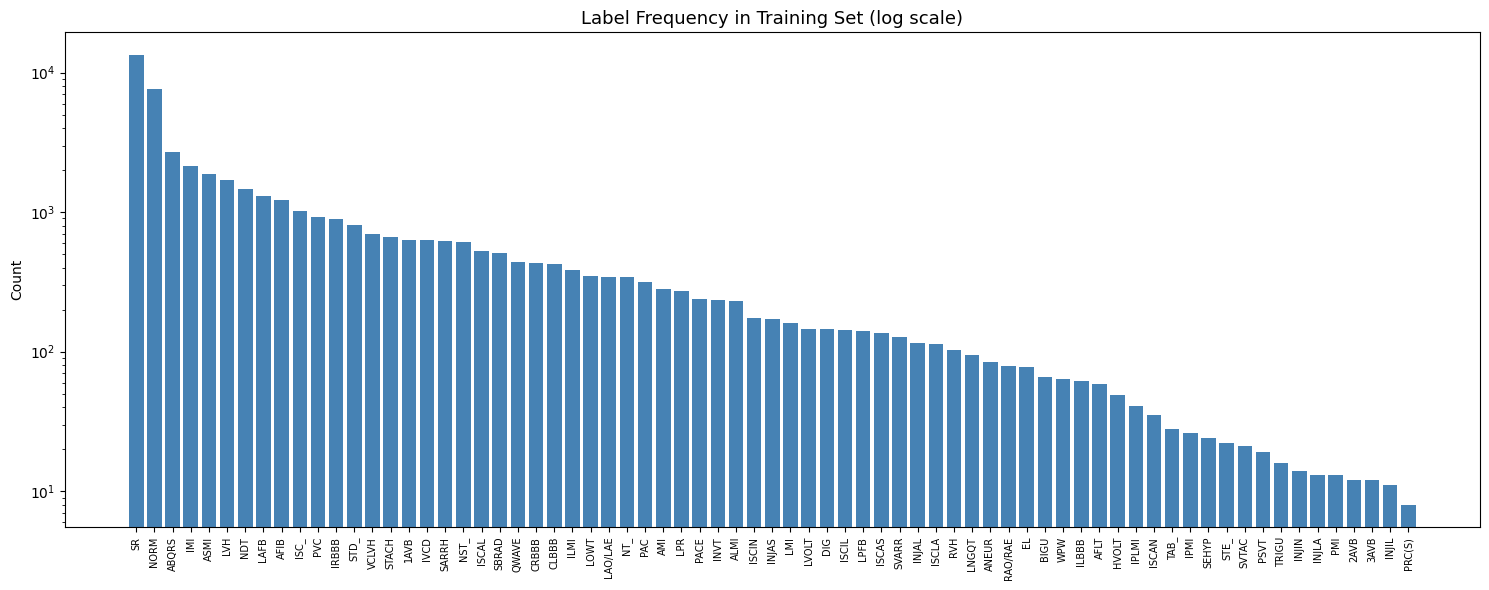

In [106]:
label_counts = y_train.sum(axis=0)

label_freq_df = pd.DataFrame({
    "label": ALL_LABELS,
    "count": label_counts,
    "frequency": label_counts / len(y_train)
}).sort_values("count", ascending=False)

fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(range(NUM_CLASSES), label_freq_df["count"].values, color="steelblue")
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(label_freq_df["label"].values, rotation=90, fontsize=7)
ax.set_yscale("log")
ax.set_title("Label Frequency in Training Set (log scale)", fontsize=13)
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


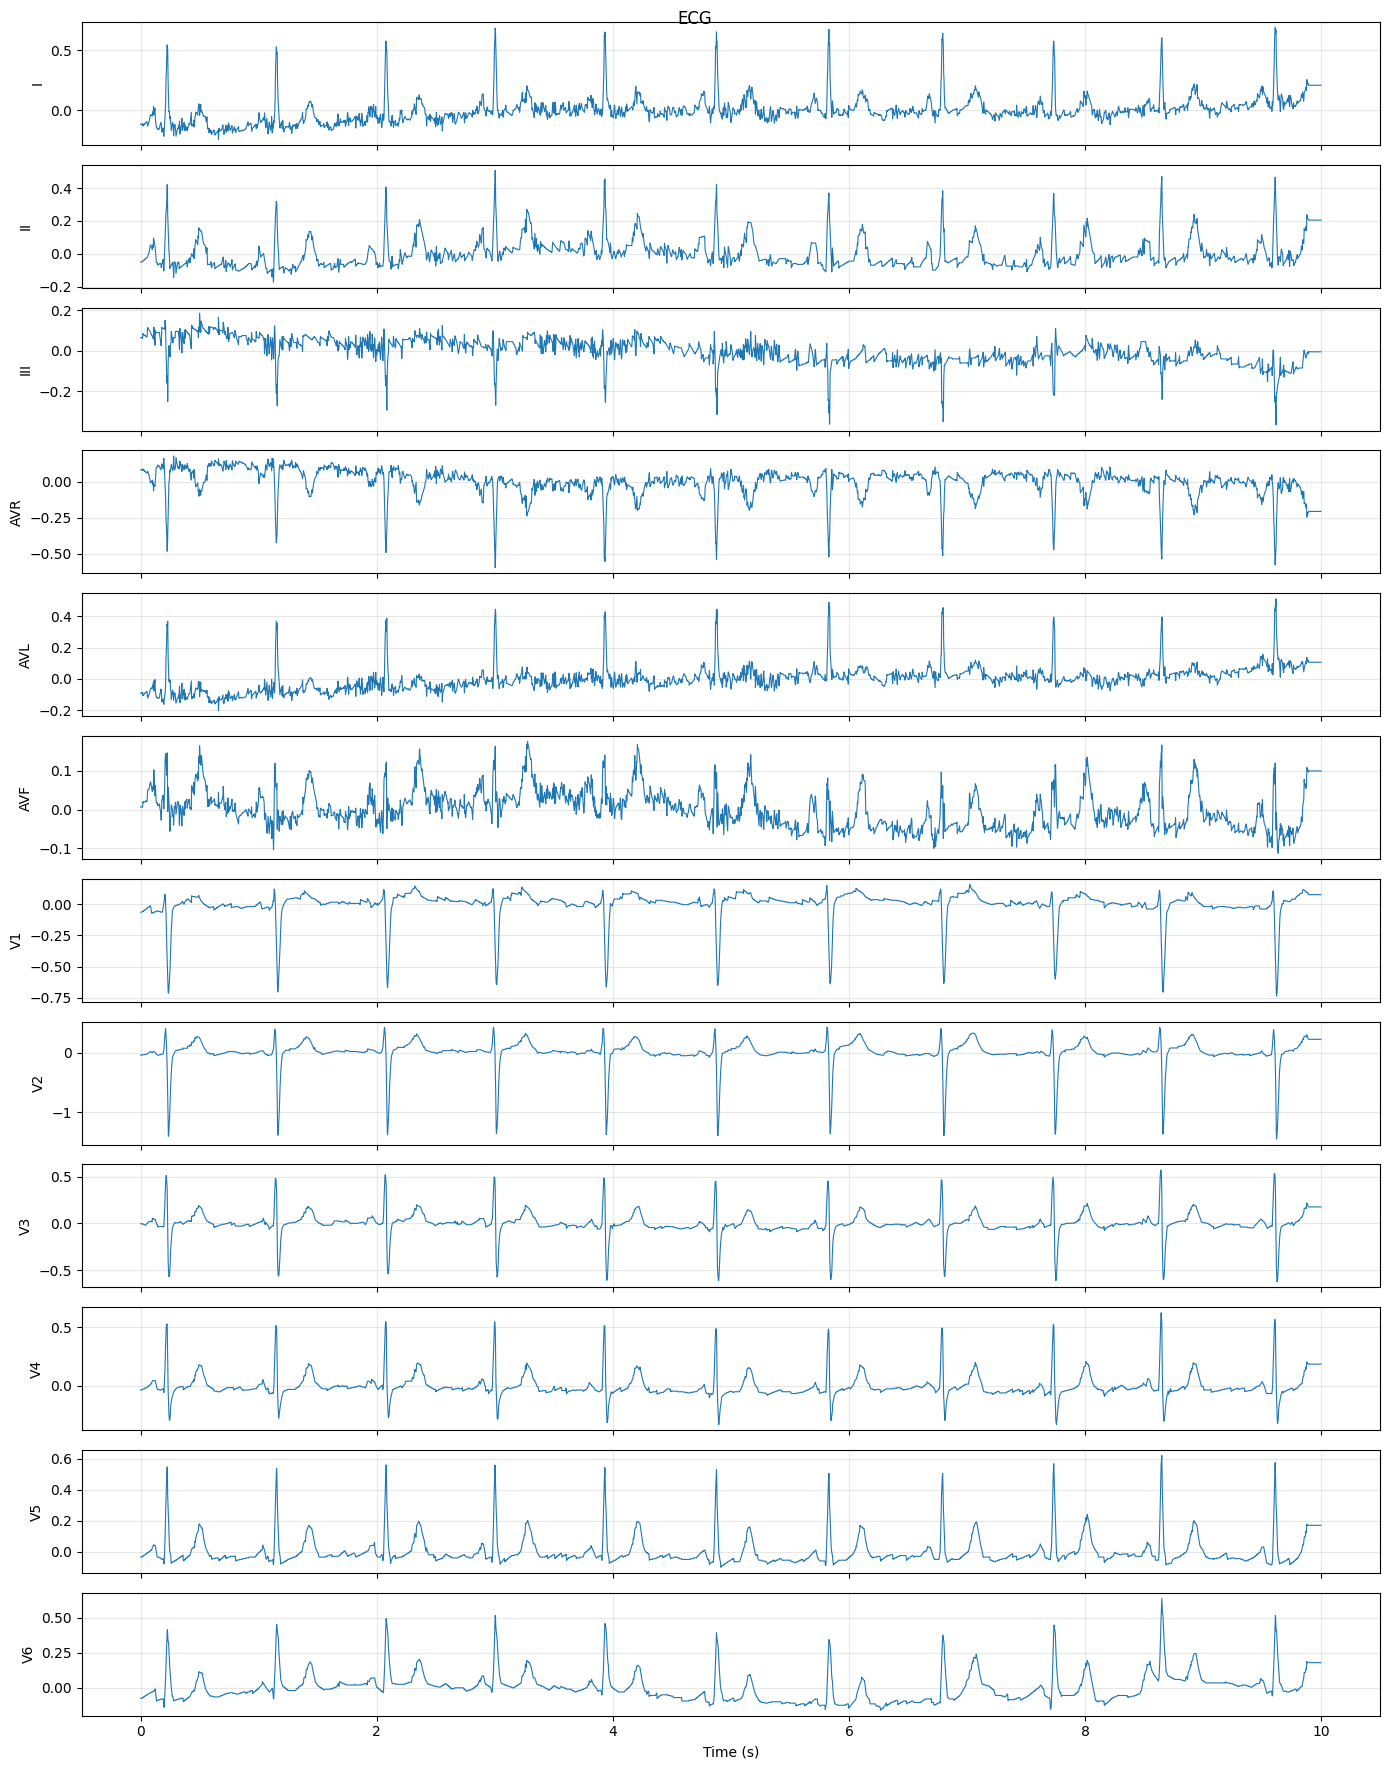

In [107]:
import matplotlib.pyplot as plt
signal, metadata = wfdb.rdsamp(r'D:\\AOU-Graduation-Project\\BioIntellect\\AI\\ECG\\Data\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00001_hr')
def plot_12_lead_ecg(signal, lead_names, fs, title="ECG"):
    n_samples, n_leads = signal.shape
    t = np.arange(n_samples) / fs

    fig, axes = plt.subplots(n_leads, 1, figsize=(14, 18), sharex=True)
    for i in range(n_leads):
        axes[i].plot(t, signal[:, i], linewidth=0.8)
        axes[i].set_ylabel(lead_names[i])
        axes[i].grid(True, alpha=0.3)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_12_lead_ecg(signal, metadata["sig_name"], metadata["fs"])

In [108]:
def quality_check(ecg: np.ndarray, fs=500) -> dict:

    report = {}
    
    # NaN / Inf
    report["has_nan"]  = np.isnan(ecg).any()
    report["has_inf"]  = np.isinf(ecg).any()
    
    # Flatline detection 
    flat_leads = []
    for i in range(ecg.shape[1]):
        if ecg[:, i].std() < 1e-6:
            flat_leads.append(i)
    report["flat_leads"] = flat_leads
    
    report["amplitude_ok"] = (
        np.abs(ecg).max() < 50.0  
    )
    
    # Saturation check
    saturation_ratio = (np.abs(ecg) > 10.0).mean()
    report["saturation_ratio"] = saturation_ratio
    report["is_saturated"] = saturation_ratio > 0.05
    
    # Overall quality
    report["is_valid"] = (
        not report["has_nan"] and
        not report["has_inf"] and
        len(report["flat_leads"]) == 0 and
        report["amplitude_ok"] and
        not report["is_saturated"]
    )
    
    return report


def fix_signal(ecg: np.ndarray) -> np.ndarray:

    ecg = np.nan_to_num(ecg, nan=0.0, posinf=0.0, neginf=0.0)
    
    for i in range(ecg.shape[1]):
        if ecg[:, i].std() < 1e-6:
            if i > 0:
                ecg[:, i] = ecg[:, i-1]  # copy من lead جنبها
            else:
                ecg[:, i] = np.zeros(ecg.shape[0])
    
    return ecg

In [109]:
def remove_baseline_wander(ecg: np.ndarray, fs=500) -> np.ndarray:
    """
    إزالة الانجراف البطيء بسبب التنفس والحركة
    أفضل من High-pass filter وحده
    """
    corrected = np.zeros_like(ecg, dtype=np.float32)
    
    for i in range(ecg.shape[1]):
        # Wavelet-based baseline removal
        wavelet = 'db4'
        level   = 9
        
        coeffs = pywt.wavedec(ecg[:, i], wavelet, level=level)
        
        # إزالة الـ low frequency components (baseline)
        coeffs[0] = np.zeros_like(coeffs[0])  # approx coefficients
        coeffs[1] = np.zeros_like(coeffs[1])
        
        corrected[:, i] = pywt.waverec(coeffs, wavelet)[:ecg.shape[0]]
    
    return corrected

In [110]:
def remove_powerline_noise(ecg: np.ndarray,fs=500,freq=50.0) -> np.ndarray:

    # Notch Filter
    b, a = scipy_signal.iirnotch(freq, Q=30, fs=fs)
    
    filtered = np.zeros_like(ecg, dtype=np.float32)
    for i in range(ecg.shape[1]):
        filtered[:, i] = scipy_signal.filtfilt(b, a, ecg[:, i])
    
    # إزالة الـ harmonics أيضاً (100Hz, 150Hz)
    for harmonic in [100.0, 150.0]:
        if harmonic < fs / 2:
            b, a = scipy_signal.iirnotch(harmonic, Q=30, fs=fs)
            for i in range(ecg.shape[1]):
                filtered[:, i] = scipy_signal.filtfilt(
                    b, a, filtered[:, i]
                )
    
    return filtered

In [111]:
def bandpass_filter(ecg: np.ndarray,lowcut=0.5, highcut=40.0,fs=500, order=4) -> np.ndarray:

    nyquist = fs / 2.0
    
    # تأكد إن الـ cutoff frequencies صح
    lowcut  = max(lowcut,  0.1)
    highcut = min(highcut, nyquist - 1)
    
    sos = scipy_signal.butter(
        order,
        [lowcut / nyquist, highcut / nyquist],
        btype="bandpass",
        output="sos"
    )
    
    filtered = np.zeros_like(ecg, dtype=np.float32)
    for i in range(ecg.shape[1]):
        filtered[:, i] = scipy_signal.sosfiltfilt(sos, ecg[:, i])
    
    return filtered

In [ ]:
def wavelet_denoise(ecg: np.ndarray, wavelet='db6', level=4) -> np.ndarray:

    denoised = np.zeros_like(ecg, dtype=np.float32)
    
    for i in range(ecg.shape[1]):
        coeffs = pywt.wavedec(ecg[:, i], wavelet, level=level)
        
        # حساب الـ threshold 
        sigma = np.median(np.abs(coeffs[-1])) / 0.6745
        threshold = sigma * np.sqrt(2 * np.log(len(ecg[:, i])))
        
        # تطبيق الـ soft thresholding
        coeffs_thresh = [pywt.threshold(c, threshold, mode='soft') 
                         for c in coeffs]
        coeffs_thresh[0] = coeffs[0] 
        
        denoised[:, i] = pywt.waverec(
            coeffs_thresh, wavelet
        )[:ecg.shape[0]]
    
    return denoised

In [113]:
def normalize_ecg(ecg: np.ndarray, method="robust_zscore") -> np.ndarray:

    eps = 1e-8
    
    if method == "per_lead_zscore":
        mean = ecg.mean(axis=0, keepdims=True)
        std  = ecg.std(axis=0,  keepdims=True)
        return ((ecg - mean) / (std + eps)).astype(np.float32)
    
    elif method == "clip_zscore":
        mean = ecg.mean(axis=0, keepdims=True)
        std  = ecg.std(axis=0,  keepdims=True)
        return np.clip(
            (ecg - mean) / (std + eps), -4.0, 4.0
        ).astype(np.float32)
    
    elif method == "robust_zscore":
        # أفضل لأنه مش بيتأثر بالـ outliers
        median = np.median(ecg, axis=0, keepdims=True)
        mad    = np.median(
            np.abs(ecg - median), axis=0, keepdims=True
        )
        normalized = (ecg - median) / (mad * 1.4826 + eps)
        return np.clip(normalized, -4.0, 4.0).astype(np.float32)
    
    elif method == "minmax":
        min_val = ecg.min(axis=0, keepdims=True)
        max_val = ecg.max(axis=0, keepdims=True)
        return ((ecg - min_val) / 
                (max_val - min_val + eps)).astype(np.float32)
    
    else:
        raise ValueError(f"Unknown method: {method}")

In [114]:
def full_preprocess_pipeline(ecg: np.ndarray,
                              fs=500,
                              training=False,
                              use_wavelet=True,
                              return_features=False) -> dict:
    results = {}

    report = quality_check(ecg, fs)
    results["quality_report"] = report
    if not report["is_valid"]:
        ecg = fix_signal(ecg)

    ecg = remove_baseline_wander(ecg, fs)
    ecg = remove_powerline_noise(ecg, fs, freq=50.0)
    ecg = bandpass_filter(ecg, lowcut=0.5, highcut=40.0, fs=fs, order=4)

    if use_wavelet:
        ecg = wavelet_denoise(ecg, wavelet='db6', level=4)

    ecg = normalize_ecg(ecg, method="clip_zscore")
    results["processed_ecg"] = ecg
    return results

In [115]:
def preprocess_ecg(ecg: np.ndarray, fs=500, training=False) -> np.ndarray:
    result = full_preprocess_pipeline(
        ecg,
        fs=fs,
        training=training,
        use_wavelet=True,
        return_features=False
    )
    return result["processed_ecg"]

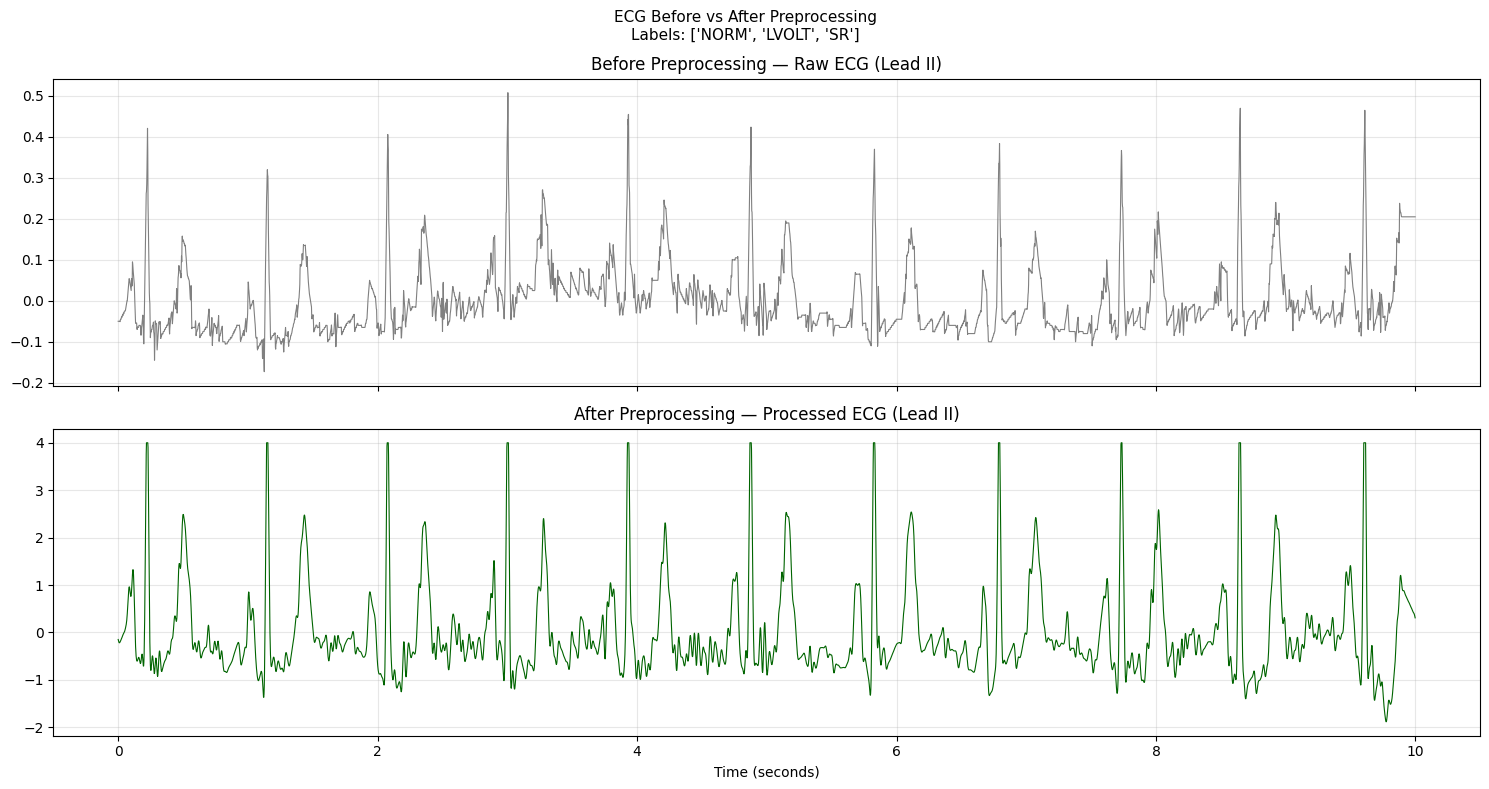

Before -> mean=0.0023, std=0.0860
After  -> mean=-0.0067, std=0.9702


In [116]:
sample_fn = str(train["filename_hr"].iloc[0]).replace(".hea", "")
full_path = os.path.normpath(
    sample_fn if os.path.isabs(sample_fn) else os.path.join(BASE_PATH, sample_fn)
)

raw_ecg, meta = wfdb.rdsamp(full_path)
proc_ecg = preprocess_ecg(raw_ecg.copy())

fs = 500
time_axis = np.arange(raw_ecg.shape[0]) / fs
lead_idx = 1   # Lead II

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Before preprocessing
axes[0].plot(time_axis, raw_ecg[:, lead_idx], color="gray", linewidth=0.8)
axes[0].set_title("Before Preprocessing — Raw ECG (Lead II)", fontsize=12)
axes[0].grid(alpha=0.3)

# After preprocessing
axes[1].plot(time_axis, proc_ecg[:, lead_idx], color="darkgreen", linewidth=0.8)
axes[1].set_title("After Preprocessing — Processed ECG (Lead II)", fontsize=12)
axes[1].set_xlabel("Time (seconds)")
axes[1].grid(alpha=0.3)

plt.suptitle(
    f"ECG Before vs After Preprocessing\nLabels: {list(train['scp_codes'].iloc[0].keys())}",
    fontsize=11
)
plt.tight_layout()
plt.show()

print(f"Before -> mean={raw_ecg[:, lead_idx].mean():.4f}, std={raw_ecg[:, lead_idx].std():.4f}")
print(f"After  -> mean={proc_ecg[:, lead_idx].mean():.4f}, std={proc_ecg[:, lead_idx].std():.4f}")


In [ ]:
# Training
train_result = full_preprocess_pipeline(
    raw_ecg, 
    fs=500, 
    training=True,
    use_wavelet=True,
    return_features=False
)

# Inference
test_result = full_preprocess_pipeline(
    raw_ecg, 
    fs=500, 
    training=False,
    use_wavelet=True,
    return_features=False
)

processed = train_result["processed_ecg"]
print(f" Shape: {processed.shape}")
print(f" جودة الإشارة: {train_result['quality_report']['is_valid']}")

✅ Shape: (5000, 12)
✅ جودة الإشارة: True


In [ ]:
def load_all_signals(df_split, base_path, fs=500):

    signals = []
    skipped = 0
    total   = len(df_split)

    for i, fn in enumerate(df_split["filename_hr"]):
        fn_clean  = str(fn).replace(".hea", "")
        full_path = os.path.normpath(
            fn_clean if os.path.isabs(fn_clean) 
            else os.path.join(base_path, fn_clean))

        try:
            raw, _ = wfdb.rdsamp(full_path)
            ecg    = raw.astype(np.float32)

            report = quality_check(ecg, fs)
            if not report["is_valid"]:
                ecg = fix_signal(ecg)

            #  Full pipeline
            proc = preprocess_ecg(ecg, fs=fs, training=False)
            signals.append(proc)

        except Exception as e:
            print(f"Skipped {fn}: {e}")
            # نحط إشارة صفر بدل ما نوقف الـ loading
            signals.append(np.zeros((5000, 12), dtype=np.float32))
            skipped += 1

        if (i + 1) % 1000 == 0:
            print(f"  Loaded {i+1}/{total} | Skipped: {skipped}")

    signals = np.stack(signals, axis=0)
    print(f"✅ Done. Shape: {signals.shape} | Skipped: {skipped}")
    return signals


print("Loading train signals...")
X_train = load_all_signals(train, BASE_PATH) 

print("\nLoading val signals...")
X_val   = load_all_signals(val,   BASE_PATH) 

print("\nLoading test signals...")
X_test  = load_all_signals(test,  BASE_PATH) 

Loading train signals...
  Loaded 1000/17418 | Skipped: 0
  Loaded 2000/17418 | Skipped: 0
  Loaded 3000/17418 | Skipped: 0
  Loaded 4000/17418 | Skipped: 0
  Loaded 5000/17418 | Skipped: 0
  Loaded 6000/17418 | Skipped: 0
  Loaded 7000/17418 | Skipped: 0
  Loaded 8000/17418 | Skipped: 0
  Loaded 9000/17418 | Skipped: 0
  Loaded 10000/17418 | Skipped: 0
  Loaded 11000/17418 | Skipped: 0
  Loaded 12000/17418 | Skipped: 0
  Loaded 13000/17418 | Skipped: 0
  Loaded 14000/17418 | Skipped: 0
  Loaded 15000/17418 | Skipped: 0
  Loaded 16000/17418 | Skipped: 0
  Loaded 17000/17418 | Skipped: 0
✅ Done. Shape: (17418, 5000, 12) | Skipped: 0

Loading val signals...
  Loaded 1000/2183 | Skipped: 0
  Loaded 2000/2183 | Skipped: 0
✅ Done. Shape: (2183, 5000, 12) | Skipped: 0

Loading test signals...
  Loaded 1000/2198 | Skipped: 0
  Loaded 2000/2198 | Skipped: 0
✅ Done. Shape: (2198, 5000, 12) | Skipped: 0


pos_weights shape: (71,)
Min weight: 1.00
Max weight: 50.00
Mean weight: 39.79


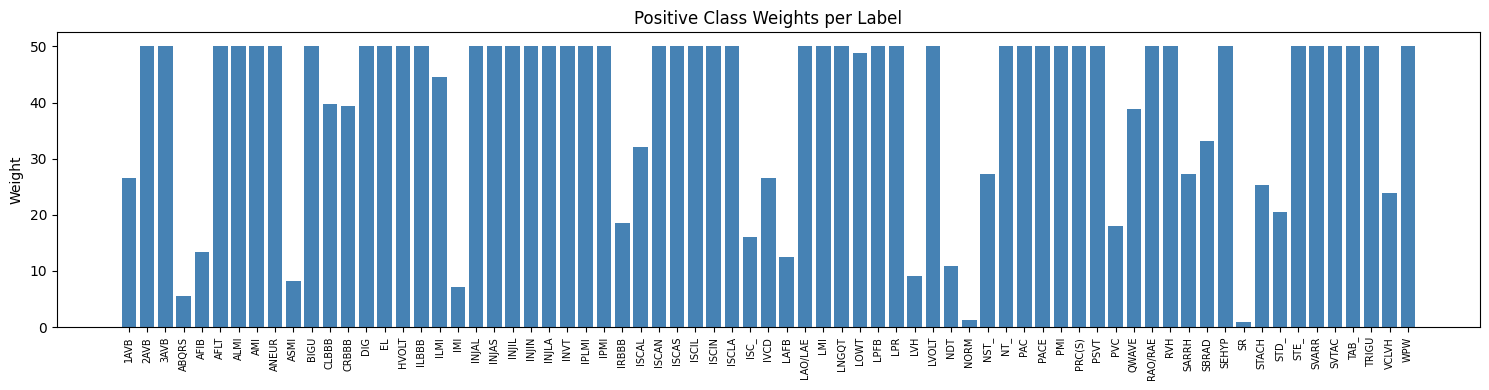

In [119]:
neg_counts = (y_train == 0).sum(axis=0)  
pos_counts = (y_train == 1).sum(axis=0) 


pos_counts_safe = np.where(pos_counts == 0, 1, pos_counts)


pos_weights = neg_counts / pos_counts_safe

pos_weights = np.clip(pos_weights, 1.0, 50.0)

pos_weights_tf = tf.constant(pos_weights, dtype=tf.float32)

print(f"pos_weights shape: {pos_weights_tf.shape}")
print(f"Min weight: {pos_weights.min():.2f}")
print(f"Max weight: {pos_weights.max():.2f}")
print(f"Mean weight: {pos_weights.mean():.2f}")

plt.figure(figsize=(15, 4))
plt.bar(range(NUM_CLASSES), pos_weights, color="steelblue")
plt.xticks(range(NUM_CLASSES), ALL_LABELS, rotation=90, fontsize=7)
plt.title("Positive Class Weights per Label")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()

### save data (no need to repate all the time all processing)
#### important to use it in the report

In [120]:
np.save("X_train_processed.npy", X_train)
np.save("X_val_processed.npy",   X_val)
np.save("X_test_processed.npy",  X_test)
np.save("pos_weights.npy",       pos_weights)

In [ ]:
y_train[0] # 71 classes

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.], dtype=float32)

### text processed

In [133]:
train_df=pd.read_csv(r"D:\AOU-Graduation-Project\BioIntellect\AI\ECG\App\classification\ptbxl_train.csv")
val_df=pd.read_csv(r"D:\AOU-Graduation-Project\BioIntellect\AI\ECG\App\classification\ptbxl_val.csv")
test_df=pd.read_csv(r"D:\AOU-Graduation-Project\BioIntellect\AI\ECG\App\classification\ptbxl_test.csv")
train_df.head()

,ecg_id,patient_id,age,sex,height,weight,report,scp_codes,validated_by_human,strat_fold,filename_hr,height_missing,weight_missing
0,1,15709.0,0.629213,1,0.794258,0.252,sinusrhythmus periphere niederspannung,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",True,3,D:\AOU-Graduation-Project\BioIntellect\AI\ECG\...,1,0
1,2,13243.0,0.213483,0,0.794258,0.280,sinusbradykardie sonst normales ekg,"{'NORM': 80.0, 'SBRAD': 0.0}",True,2,D:\AOU-Graduation-Project\BioIntellect\AI\ECG\...,1,0
2,3,20372.0,0.415730,1,0.794258,0.276,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",True,5,D:\AOU-Graduation-Project\BioIntellect\AI\ECG\...,1,0
3,4,17014.0,0.269663,0,0.794258,0.328,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",True,3,D:\AOU-Graduation-Project\BioIntellect\AI\ECG\...,1,0
4,5,17448.0,0.213483,1,0.794258,0.280,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",True,4,D:\AOU-Graduation-Project\BioIntellect\AI\ECG\...,1,0


In [134]:
def preprocess_text_labels(df):
    try:
        df.drop(columns=["filename_hr", "strat_fold","report","scp_codes","patient_id","ecg_id"], inplace=True)
    except Exception as e:
        print (f"Error preprocessing text labels: {e}")
        return 

In [135]:
preprocess_text_labels(train_df)
preprocess_text_labels(val_df)
preprocess_text_labels(test_df)

### test maching 

In [132]:
import numpy as np
import wfdb
import os

X_train = np.load("X_train_processed.npy")

i = 0
sample_fn = str(train["filename_hr"].iloc[i]).replace(".hea", "")
full_path  = os.path.normpath(os.path.join(BASE_PATH, sample_fn))

raw, _ = wfdb.rdsamp(full_path)
proc   = preprocess_ecg(raw.astype(np.float32))

diff    = np.abs(X_train[i] - proc).max()
corr    = np.corrcoef(X_train[i][:, 1], proc[:, 1])[0, 1]

print(f"Max difference : {diff:.8f}") 
print(f"Correlation    : {corr:.8f}")  

if diff < 1e-5:
    print("✅ Row 0 NPY = Row 0 DataFrame")
else:
    print("❌")

print("\n--- Multi-sample check ---")
for i in [0, 1, 100, 500, 1000]:
    fn  = str(train["filename_hr"].iloc[i]).replace(".hea", "")
    fp  = os.path.normpath(os.path.join(BASE_PATH, fn))
    raw, _ = wfdb.rdsamp(fp)
    proc   = preprocess_ecg(raw.astype(np.float32))
    diff   = np.abs(X_train[i] - proc).max()
    label  = list(train["scp_codes"].iloc[i].keys())
    print(f"  idx={i:4d} | diff={diff:.2e} | label={label}")


Max difference : 0.00000000
Correlation    : 1.00000000
✅ Row 0 NPY = Row 0 DataFrame

--- Multi-sample check ---
  idx=   0 | diff=0.00e+00 | label=['NORM', 'LVOLT', 'SR']
  idx=   1 | diff=0.00e+00 | label=['NORM', 'SBRAD']
  idx= 100 | diff=0.00e+00 | label=['NORM', 'SR']
  idx= 500 | diff=0.00e+00 | label=['IRBBB', 'SR']
  idx=1000 | diff=0.00e+00 | label=['NORM', 'SR']
